In [20]:
import sys
import os
import subprocess
from pathlib import Path

# Ensure project import path
PROJECT_ROOT = Path('/global/home/hpc5656/SLAM')
sys.path.append(str(PROJECT_ROOT))
# Set working directory so relative paths (e.g., src/config/*.yaml) resolve
os.chdir(str(PROJECT_ROOT))
print('CWD:', Path.cwd())

%matplotlib inline

# Enable autoreload for development (automatically reloads modules when they change)
%load_ext autoreload
%autoreload 2

# CuPy is required - ensure CUDA_PATH and LD_LIBRARY_PATH are set
# This allows the notebook to work even if Jupyter wasn't started with modules loaded
if "CUDA_PATH" not in os.environ:
    print("CUDA_PATH not set, attempting to load modules...")
    try:
        result = subprocess.run(
            'module load cuda/12.2 && env',
            shell=True,
            executable='/bin/bash',
            capture_output=True,
            text=True,
            timeout=10
        )
        if result.returncode == 0:
            for line in result.stdout.split('\n'):
                if '=' in line:
                    key, value = line.split('=', 1)
                    os.environ[key] = value
            print(f"✓ Modules loaded. CUDA_PATH: {os.environ.get('CUDA_PATH', 'Not set')}")
        else:
            print(f"⚠ Could not load modules. Error: {result.stderr}")
            raise RuntimeError(
                "CUDA_PATH not set and could not load modules. "
                "Please run: module load cuda/12.2 before starting Jupyter."
            )
    except Exception as e:
        print(f"✗ Could not load modules: {e}")
        raise RuntimeError(
            f"Failed to load CUDA modules: {e}\n"
            "Please ensure CUDA is loaded before starting Jupyter:\n"
            "  module load cuda/12.2"
        ) from e

# Ensure LD_LIBRARY_PATH includes CUDA library directory for NVRTC (libnvrtc.so.12)
# This is required for CuPy to compile kernels at runtime
# Note: Setting this BEFORE importing CuPy is critical
cuda_path = os.environ.get('CUDA_PATH')
libnvrtc_path = None

if cuda_path:
    # Check both standard location and Compute Canada's targets/x86_64-linux/lib location
    cuda_lib_paths = [
        os.path.join(cuda_path, 'lib64'),  # Standard location
        os.path.join(cuda_path, 'targets', 'x86_64-linux', 'lib'),  # Compute Canada location
    ]
    
    current_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    ld_paths = current_ld_path.split(':') if current_ld_path else []
    paths_added = []
    
    # Find which paths exist and add them to LD_LIBRARY_PATH
    for cuda_lib_path in cuda_lib_paths:
        if os.path.exists(cuda_lib_path):
            if cuda_lib_path not in ld_paths:
                paths_added.append(cuda_lib_path)
                ld_paths.insert(0, cuda_lib_path)  # Prepend for priority
    
    if paths_added:
        os.environ['LD_LIBRARY_PATH'] = ':'.join(ld_paths)
        print(f"✓ Updated LD_LIBRARY_PATH to include: {', '.join(paths_added)}")
    else:
        # Check if paths were already included
        found_paths = [p for p in cuda_lib_paths if p in ld_paths]
        if found_paths:
            print(f"✓ LD_LIBRARY_PATH already includes CUDA libraries: {', '.join(found_paths)}")
    
    # Find libnvrtc.so.12 and preload it using ctypes
    # This ensures CuPy can find it even if LD_LIBRARY_PATH isn't fully respected
    for cuda_lib_path in cuda_lib_paths:
        if os.path.exists(cuda_lib_path):
            potential_libnvrtc = os.path.join(cuda_lib_path, 'libnvrtc.so.12')
            if os.path.exists(potential_libnvrtc):
                libnvrtc_path = potential_libnvrtc
                print(f"✓ Found libnvrtc.so.12 at: {libnvrtc_path}")
                
                # Preload the library using ctypes so CuPy can find it
                # Use RTLD_GLOBAL to make symbols available to other libraries
                try:
                    import ctypes
                    # Try multiple loading strategies
                    try:
                        # Strategy 1: Load with full path and RTLD_GLOBAL
                        lib = ctypes.CDLL(libnvrtc_path, mode=ctypes.RTLD_GLOBAL)
                        print(f"✓ Preloaded libnvrtc.so.12 using ctypes (RTLD_GLOBAL)")
                    except Exception as e1:
                        # Strategy 2: Try without RTLD_GLOBAL
                        try:
                            lib = ctypes.CDLL(libnvrtc_path)
                            print(f"✓ Preloaded libnvrtc.so.12 using ctypes (standard)")
                        except Exception as e2:
                            raise e1 from e2
                except Exception as e:
                    print(f"⚠ Warning: Could not preload libnvrtc.so.12: {e}")
                    print(f"  CuPy may still work if LD_LIBRARY_PATH is set correctly")
                    print(f"  You may need to restart the Jupyter kernel with:")
                    print(f"    export LD_LIBRARY_PATH={os.path.dirname(libnvrtc_path)}:$LD_LIBRARY_PATH")
                
                # Verify that ctypes can find the library by name (as CuPy will try)
                try:
                    import ctypes.util
                    found_lib = ctypes.util.find_library('nvrtc')
                    if found_lib:
                        print(f"✓ ctypes.util.find_library('nvrtc') found: {found_lib}")
                    else:
                        print(f"⚠ ctypes.util.find_library('nvrtc') returned None")
                        print(f"  This may cause issues. Try loading by name:")
                        try:
                            test_lib = ctypes.CDLL('libnvrtc.so.12')
                            print(f"✓ Successfully loaded libnvrtc.so.12 by name")
                        except Exception as name_err:
                            print(f"✗ Failed to load libnvrtc.so.12 by name: {name_err}")
                            print(f"  You MUST restart the Jupyter kernel with LD_LIBRARY_PATH set")
                except Exception as diag_err:
                    print(f"⚠ Could not run diagnostics: {diag_err}")
                break
    
    if not libnvrtc_path:
        # Try to find any version of libnvrtc.so
        import glob
        for cuda_lib_path in cuda_lib_paths:
            if os.path.exists(cuda_lib_path):
                nvrtc_files = glob.glob(os.path.join(cuda_lib_path, 'libnvrtc.so*'))
                if nvrtc_files:
                    # Try to use the most specific version
                    nvrtc_files.sort(reverse=True)  # Prefer .so.12.2.140 over .so.12 over .so
                    potential_lib = nvrtc_files[0]
                    print(f"⚠ libnvrtc.so.12 not found, but found: {nvrtc_files}")
                    print(f"  Attempting to use: {potential_lib}")
                    try:
                        import ctypes
                        ctypes.CDLL(potential_lib, mode=ctypes.RTLD_GLOBAL)
                        print(f"✓ Preloaded {potential_lib} using ctypes")
                        libnvrtc_path = potential_lib
                    except Exception as e:
                        print(f"⚠ Could not preload {potential_lib}: {e}")
                    break
        else:
            print(f"⚠ Warning: libnvrtc.so.12 not found in any CUDA library directory")
            print(f"  This may cause CuPy kernel compilation to fail")
else:
    print("⚠ CUDA_PATH not set, cannot configure LD_LIBRARY_PATH")

# Use CuPy backend for GPU acceleration (falls back to NumPy if not available)
from src.utils.array_backend import np, random, is_cupy
from src.classes.belief_mdp_n import BeliefMDP_n_SLAM
import numpy as np_cpu  # Import NumPy explicitly for CPU operations
from src.classes.model import DoubleIntegratorModel, LIDAR
from src.classes.mapping import LidarGridMapVec
from src.utils.map import load_obstacles_config
from tqdm import tqdm
import time

print(f"✓ All imports successful")
print(f"Using backend: {'CuPy (GPU)' if is_cupy else 'NumPy (CPU)'}")

# Verify we're using CuPy
if not is_cupy:
    raise RuntimeError(
        "CuPy is required but not being used. "
        "Check CUDA installation and CuPy setup."
    )

"""
Verification tests for F function (filter update) in BeliefMDP_n.

Tests:
1. F, F_batch, and F_batch_log comparison
2. Numerical agreement validation
3. Performance comparison

Uses the same model as T_mat_visuals.ipynb:
- DoubleIntegratorModel with n=4, dt=1.0, max_a=2.0
- LIDAR(fov=360, r_max=10.0, B=8)
"""


CWD: /global/home/hpc5656/SLAM
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ LD_LIBRARY_PATH already includes CUDA libraries: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2/lib64, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2/targets/x86_64-linux/lib
✓ Found libnvrtc.so.12 at: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/cudacore/12.2.2/lib64/libnvrtc.so.12
✓ Preloaded libnvrtc.so.12 using ctypes (RTLD_GLOBAL)
✓ ctypes.util.find_library('nvrtc') found: libnvrtc.so.12
✓ All imports successful
Using backend: CuPy (GPU)


'\nVerification tests for F function (filter update) in BeliefMDP_n.\n\nTests:\n1. F, F_batch, and F_batch_log comparison\n2. Numerical agreement validation\n3. Performance comparison\n\nUses the same model as T_mat_visuals.ipynb:\n- DoubleIntegratorModel with n=4, dt=1.0, max_a=2.0\n- LIDAR(fov=360, r_max=10.0, B=8)\n'

In [21]:
# Setup: Create BeliefMDP_n_SLAM instance and run F function updates
print("="*70)
print("F Function Visualization Test")
print("="*70)

# Configuration
quantization_level = 3
n_updates = 15  # Number of belief updates to perform

# Create model
obstacles, area = load_obstacles_config(environment='toy2')
motion_model = DoubleIntegratorModel(p_x=5.0, p_y=5.0, v_x=0.0, v_y=0.0, dt=0.5, max_a=2.0)
sensor = LIDAR(fov=360, r_max=10.0, B=8)
grid_map = LidarGridMapVec(
    x_min=area[0], x_max=area[1],
    y_min=area[2], y_max=area[3],
    quantization_level=quantization_level,
)

bmdp = BeliefMDP_n_SLAM(
    n=quantization_level,
    motion_model=motion_model,
    measurement_model=sensor,
    obstacles=obstacles,
    _map=grid_map,
    sigma_w=0.01,  # Process noise (default)
    sigma_v=1.0    # Measurement noise
)

# Manually set map using NumPy array for easier debugging
# Array format: first row = top of map, last row = bottom of map
# 1 = occupied, 0 = free
# This is already in (H, W) format where row 0 = top
map = np_cpu.array([[1, 0, 1],  # Top row: left and right occupied
                    [0, 0, 0],  # Middle row: all free
                    [0, 0, 0]]) # Bottom row: all free

# Convert to map bits for reference (map_to_bits expects (H, W) with row 0 = top)
map_bits = bmdp.map.map_to_bits(map)
print(f"Map bits: {map_bits}")

# Set the occupancy map data
# GridMapNP.data is stored as (width, height) = (x_ind, y_ind)
# map is (H, W) = (height, width), so we transpose to get (width, height)
bmdp.map.occupancy_map.data = np.array(map.T, dtype=bmdp.map.occupancy_map.data_type)

print(f"\nModel created:")
print(f"  Quantization level: {quantization_level}")
print(f"  Map size: {quantization_level}x{quantization_level} = {quantization_level**2} cells")
print(f"  Total maps: 2^{quantization_level**2} = {2**(quantization_level**2)}")
print(f"  State space size: {bmdp.SQ.m_n}")

# Get ground truth indices (for creating priors)
# Find state closest to middle position (for 3x3 grid, middle is at center of area)
X_n = bmdp.SQ.X_n
x_middle_raw = np.array([(area[0] + area[1]) / 2, (area[2] + area[3]) / 2])  # Middle of the area
# Convert to NumPy if it's CuPy
if hasattr(x_middle_raw, 'get'):
    x_middle = x_middle_raw.get()
else:
    x_middle = np_cpu.asarray(x_middle_raw)
if X_n.shape[1] >= 2:
    x_dists = np.linalg.norm(X_n[:, :2] - x_middle_raw, axis=1)  # Use raw for distance computation
else:
    x_dists = np.linalg.norm(X_n - x_middle_raw, axis=1)
X_ind = int(np.argmin(x_dists))

# Find map index that matches our manually set map
# Use the original map array (row 0 = top) for map_to_bits
H, W = bmdp.map_H, bmdp.map_W
M_size = bmdp.len_M
M_ind_gt = int(map_bits)  # Use the map bits we computed above
print(f"Ground truth map index: {M_ind_gt}")

# Create prior: state_known_map_uniform (state is known, map is uniform)
m_n = bmdp.SQ.m_n
state_prior = np.zeros(m_n, dtype=np.float64)
state_prior[X_ind] = 1.0
map_prior = np.full(M_size, 1.0 / M_size, dtype=np.float64)
π_0 = np.outer(state_prior, map_prior)  # (m_n, M_size)

print(f"\nPrior belief:")
print(f"  State: known at index {X_ind} (position: {X_n[X_ind, :2] if X_n.shape[1] >= 2 else X_n[X_ind]})")
print(f"  Map: uniform over {M_size} maps")

# Set initial robot position to middle
bmdp.motion_model.x = np.array([x_middle[0], x_middle[1], 0.0, 0.0]) if bmdp.state_dim == 4 else np.array([x_middle[0], x_middle[1]])

# Prepare obstacle segments for observations
# IMPORTANT: Use obstacle segments from the ground truth map, not from config obstacles
# This ensures measurements match the displayed ground truth map
all_obstacle_segments = []
for obs in obstacles:
    all_obstacle_segments += list(obs._Obstacle__get_points(obs.centroid))

# Also compute obstacle segments from the ground truth map for accurate measurements
# The ground truth map is stored in bmdp.map.occupancy_map.data, but we need to use our manually set map
# Convert map to the format expected by get_obstacles_from_map: (H, W) with row 0 = top
ground_truth_map_for_segments = map.copy()  # This is already (H, W) with row 0 = top
print(f"\nComputing obstacle segments from ground truth map:")
print(f"  Map shape: {ground_truth_map_for_segments.shape}")
print(f"  Map contents:\n{ground_truth_map_for_segments}")

ground_truth_obstacle_segments = bmdp.sensor.get_obstacles_from_map(ground_truth_map_for_segments, bmdp.map)
print(f"  Computed {len(ground_truth_obstacle_segments)} obstacle segments from ground truth map")
if len(ground_truth_obstacle_segments) > 0:
    print(f"  First few segments: {ground_truth_obstacle_segments[:2]}")

# Also compute from config obstacles for comparison
config_obstacle_segments = []
for obs in obstacles:
    config_obstacle_segments += list(obs._Obstacle__get_points(obs.centroid))
print(f"  Original obstacle segments from config: {len(config_obstacle_segments)}")

# Use ground truth map segments for measurements (this ensures consistency with visualization)
all_obstacle_segments = ground_truth_obstacle_segments
print(f"  Using {len(all_obstacle_segments)} obstacle segments for LIDAR measurements\n")

# Action for updates
u = np.array([-1.0, -1.0])

# Run belief updates
print(f"\nRunning {n_updates} belief updates...")
π = π_0.copy()
true_pos = bmdp.motion_model.x[:2] if bmdp.state_dim == 4 else bmdp.motion_model.x

# Track ground truth positions, actions, measurements, and beliefs at each step for visualization
ground_truth_positions = []
ground_truth_actions = []
ground_truth_measurements = []  # Store LIDAR measurements at each step
belief_history = []  # Store belief at each step

# Store initial position and belief
ground_truth_positions.append(true_pos.copy())
belief_history.append(π.copy())

for i in range(n_updates):
    # Store action for this step
    ground_truth_actions.append(u.copy())
    
    # Update robot position
    # DoubleIntegratorModel uses f_bar, SingleIntegratorModel uses update
    if isinstance(bmdp.motion_model, DoubleIntegratorModel):
        # For DoubleIntegratorModel, use f_bar to compute next state
        bmdp.motion_model.x = bmdp.motion_model.f_bar(bmdp.motion_model.x, u)
        true_pos = bmdp.motion_model.x[:2]
    else:
        # For SingleIntegratorModel, use update method
        true_pos = bmdp.motion_model.update(u)
        if bmdp.state_dim == 4:
            true_pos = true_pos[:2]
    
    # Store updated position
    ground_truth_positions.append(true_pos.copy())
    
    # Get observation
    y = bmdp.sensor.get_laser_ref(all_obstacle_segments, true_pos)
    if y.ndim == 1:
        y = y[np.newaxis, :]
    
    # Update belief using F function
    π = bmdp.F(π, u, y)[0]
    
    # Store belief after update
    belief_history.append(π.copy())

# Compute marginals
state_prior_marginal = π_0.sum(axis=1)
state_prior_marginal = state_prior_marginal / state_prior_marginal.sum()

map_prior_marginal = π_0.sum(axis=0)
map_prior_marginal = map_prior_marginal / map_prior_marginal.sum()

posterior_state = π.sum(axis=1)
posterior_state = posterior_state / posterior_state.sum()

posterior_map = π.sum(axis=0)
posterior_map = posterior_map / posterior_map.sum()

# Generate map matrix M
M = np.zeros((M_size, H * W), dtype=np.float64)
for j in range(M_size):
    m_j = bmdp.map.bits_to_map(j, (H, W))
    M[j] = m_j.flatten()

# Helper function to convert CuPy arrays to NumPy
def to_numpy_helper(arr):
    """Convert CuPy array to NumPy array."""
    if hasattr(arr, 'get'):
        result = arr.get()
        if hasattr(result, 'item') and result.ndim == 0:
            return result.item()
        return result
    if hasattr(arr, 'item') and arr.ndim == 0:
        return arr.item()
    return arr

# Get ground truth map - use the original map array (row 0 = top) for consistency
# This matches what we defined above: [[1, 0, 1], [0, 0, 0], [0, 0, 0]]
ground_truth_map = map.copy()  # Use the original map array (row 0 = top)

# Convert ground truth positions, actions, and measurements to NumPy for visualization
ground_truth_positions_np = [to_numpy_helper(pos) for pos in ground_truth_positions]
ground_truth_actions_np = [to_numpy_helper(action) for action in ground_truth_actions]
ground_truth_measurements_np = [to_numpy_helper(meas) for meas in ground_truth_measurements]

# Convert belief history to NumPy for visualization
belief_history_np = [to_numpy_helper(π_step) for π_step in belief_history]

# Format results for "state_known_map_uniform" setup
results = {
    'state_known_map_uniform': {
        'belief_mdp_n': bmdp,
        'state_prior': state_prior_marginal,
        'posterior_state': posterior_state,
        'map_prior': map_prior_marginal,
        'posterior_map': posterior_map,
        'M': M,
        'ground_truth_positions': ground_truth_positions_np,
        'ground_truth_actions': ground_truth_actions_np,
        'ground_truth_measurements': ground_truth_measurements_np,  # LIDAR measurements at each step
        'ground_truth_map': ground_truth_map,
        'belief_history': belief_history_np,  # Belief at each step
        'n_steps': n_updates,
    }
}

print(f"✓ Completed {n_updates} belief updates for 'state_known_map_uniform'")
print(f"✓ Results formatted for visualization")

# Now create "uniform_state_map_known" setup
print(f"\n{'='*70}")
print("Creating 'uniform_state_map_known' setup...")
print(f"{'='*70}")

# Reset robot position to middle (x_middle is already NumPy)
bmdp.motion_model.x = np.array([float(x_middle[0]), float(x_middle[1]), 0.0, 0.0]) if bmdp.state_dim == 4 else np.array([float(x_middle[0]), float(x_middle[1])])

# Create prior: uniform_state_map_known (state is uniform, map is known)
# Use the same ground truth map we manually set (top-left and top-right occupied)
# M_ind_gt was already computed above

state_prior_uniform = np.full(m_n, 1.0 / m_n, dtype=np.float64)
map_prior_known = np.zeros(M_size, dtype=np.float64)
map_prior_known[M_ind_gt] = 1.0
π_0_uniform_state = np.outer(state_prior_uniform, map_prior_known)  # (m_n, M_size)

print(f"  Prior belief:")
print(f"    State: uniform over {m_n} states")
print(f"    Map: known at index {M_ind_gt}")

# Track ground truth positions, actions, measurements, and beliefs for this setup
ground_truth_positions_2 = []
ground_truth_actions_2 = []
ground_truth_measurements_2 = []  # Store LIDAR measurements at each step
belief_history_2 = []

# Store initial position and belief
true_pos_2 = bmdp.motion_model.x[:2] if bmdp.state_dim == 4 else bmdp.motion_model.x
ground_truth_positions_2.append(true_pos_2.copy())
belief_history_2.append(π_0_uniform_state.copy())

# Run belief updates
π_2 = π_0_uniform_state.copy()
for i in range(n_updates):
    # Store action for this step
    ground_truth_actions_2.append(u.copy())
    
    # Print state before update
    state_before_2 = bmdp.motion_model.x.copy()
    if hasattr(state_before_2, 'get'):
        state_before_2 = state_before_2.get()
    print(f"\nStep {i+1} (uniform_state_map_known):")
    print(f"  State before update: {state_before_2}")
    
    # Get quantized index before update
    try:
        idx_before_2 = bmdp.SQ.get_quantized_index(state_before_2)
        pos_before_2 = state_before_2[:2] if len(state_before_2) >= 2 else state_before_2
        print(f"  Quantized state index before: {idx_before_2} (position: {pos_before_2})")
    except Exception as e:
        print(f"  Could not get quantized index before: {e}")
    
    print(f"  Action: {u}")
    if hasattr(bmdp.motion_model, '_state_bounds') and bmdp.motion_model._state_bounds is not None:
        bounds_2 = bmdp.motion_model._state_bounds
        if hasattr(bounds_2, 'get'):
            bounds_2 = bounds_2.get()
        print(f"  State bounds: lower={bounds_2[:, 0]}, upper={bounds_2[:, 1]}")
    
    # Update robot position
    if isinstance(bmdp.motion_model, DoubleIntegratorModel):
        bmdp.motion_model.x = bmdp.motion_model.f_bar(bmdp.motion_model.x, u)
        true_pos_2 = bmdp.motion_model.x[:2]
    else:
        true_pos_2 = bmdp.motion_model.update(u)
        if bmdp.state_dim == 4:
            true_pos_2 = true_pos_2[:2]
    
    # Print state after update (should be projected)
    state_after_2 = bmdp.motion_model.x.copy()
    if hasattr(state_after_2, 'get'):
        state_after_2 = state_after_2.get()
    print(f"  State after update (projected): {state_after_2}")
    print(f"  Position (for visualization): {true_pos_2}")
    
    # Get quantized index after update
    try:
        idx_after_2 = bmdp.SQ.get_quantized_index(state_after_2)
        pos_after_2 = state_after_2[:2] if len(state_after_2) >= 2 else state_after_2
        print(f"  Quantized state index after: {idx_after_2} (position: {pos_after_2})")
        
        # Check if state is within bounds
        if hasattr(bmdp.motion_model, '_state_bounds') and bmdp.motion_model._state_bounds is not None:
            bounds_2 = bmdp.motion_model._state_bounds
            if hasattr(bounds_2, 'get'):
                bounds_2 = bounds_2.get()
            within_bounds_2 = np.all((state_after_2 >= bounds_2[:, 0]) & (state_after_2 <= bounds_2[:, 1]))
            if not within_bounds_2:
                print(f"  ⚠ WARNING: State is OUTSIDE bounds after projection!")
                print(f"    Violations: {np.where((state_after_2 < bounds_2[:, 0]) | (state_after_2 > bounds_2[:, 1]))[0]}")
    except Exception as e:
        print(f"  Could not get quantized index after: {e}")
    
    
    # Store updated position
    ground_truth_positions_2.append(true_pos_2.copy())
    
    # Get observation
    y = bmdp.sensor.get_laser_ref(all_obstacle_segments, true_pos_2)
    if y.ndim == 1:
        y = y[np.newaxis, :]
    
    # Store measurement for visualization
    y_np_2 = y.copy()
    if hasattr(y_np_2, 'get'):
        y_np_2 = y_np_2.get()
    ground_truth_measurements_2.append(y_np_2[0] if y_np_2.ndim > 1 else y_np_2)  # Store as 1D array
    
    # Update belief using F function
    π_2 = bmdp.F(π_2, u, y)[0]
    
    # Store belief after update
    belief_history_2.append(π_2.copy())

# Compute marginals
state_prior_marginal_2 = π_0_uniform_state.sum(axis=1)
state_prior_marginal_2 = state_prior_marginal_2 / state_prior_marginal_2.sum()

map_prior_marginal_2 = π_0_uniform_state.sum(axis=0)
map_prior_marginal_2 = map_prior_marginal_2 / map_prior_marginal_2.sum()

posterior_state_2 = π_2.sum(axis=1)
posterior_state_2 = posterior_state_2 / posterior_state_2.sum()

posterior_map_2 = π_2.sum(axis=0)
posterior_map_2 = posterior_map_2 / posterior_map_2.sum()

# Convert to NumPy
ground_truth_positions_2_np = [to_numpy_helper(pos) for pos in ground_truth_positions_2]
ground_truth_actions_2_np = [to_numpy_helper(action) for action in ground_truth_actions_2]
ground_truth_measurements_2_np = [to_numpy_helper(meas) for meas in ground_truth_measurements_2]
belief_history_2_np = [to_numpy_helper(π_step) for π_step in belief_history_2]

# Add to results
results['uniform_state_map_known'] = {
    'belief_mdp_n': bmdp,
    'state_prior': state_prior_marginal_2,
    'posterior_state': posterior_state_2,
    'map_prior': map_prior_marginal_2,
    'posterior_map': posterior_map_2,
    'M': M,
    'ground_truth_positions': ground_truth_positions_2_np,
    'ground_truth_actions': ground_truth_actions_2_np,
    'ground_truth_measurements': ground_truth_measurements_2_np,  # LIDAR measurements at each step
    'ground_truth_map': ground_truth_map,
    'belief_history': belief_history_2_np,
    'n_steps': n_updates,
}

print(f"✓ Completed {n_updates} belief updates for 'uniform_state_map_known'")
print(f"✓ All results formatted for visualization")


F Function Visualization Test
Loaded cached T_mat from /global/home/hpc5656/SLAM/cache/T_mat/T_mat_n3_map3x3_max2.0_ce5babbc.npz
  Checking cache file: Q_n_n3_obs3_map3x3_B8_6c1b234b.npz
  ✓ Cache metadata matches, loading Q_n
Loaded cached Q_n from /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n3_obs3_map3x3_B8_6c1b234b.npz
Map bits: 5

Model created:
  Quantization level: 3
  Map size: 3x3 = 9 cells
  Total maps: 2^9 = 512
  State space size: 81
Ground truth map index: 5

Prior belief:
  State: known at index 36 (position: [5. 5.])
  Map: uniform over 512 maps

Computing obstacle segments from ground truth map:
  Map shape: (3, 3)
  Map contents:
[[1 0 1]
 [0 0 0]
 [0 0 0]]
  Computed 8 obstacle segments from ground truth map
  First few segments: [(array(0.), array(6.66666667), array(3.33333333), array(6.66666667)), (array(0.), array(10.), array(3.33333333), array(10.))]
  Original obstacle segments from config: 8
  Using 8 obstacle segments for LIDAR measurements


Running 15 belief upda

In [22]:
# Import and adapt visualize_results from test file
import sys
from pathlib import Path
import numpy as np_cpu  # Import NumPy explicitly for matplotlib

# Add test directory to path to import visualize_results
test_dir = PROJECT_ROOT / 'test'
sys.path.insert(0, str(test_dir))
import matplotlib.pyplot as plt


def to_numpy(arr):
    """Convert CuPy array to NumPy array for matplotlib compatibility."""
    if hasattr(arr, 'get'):
        return arr.get()
    return arr

def visualize_F_results(results: dict):
    """
    Adapted visualize_results that works with BeliefMDP_n_SLAM (uses SQ instead of state_quantizer).
    
    Args:
        results: Dictionary with format expected by visualize_results
        output_dir: Output directory for figures
    """
    # Note: output_dir parameter kept for compatibility but not used (plots displayed inline)
    
    first = next(iter(results.values()))
    bmdp = first['belief_mdp_n']
    H, W = bmdp.map_H, bmdp.map_W
    x_min_raw, y_min_raw = bmdp.map.left_lower
    x_max_raw, y_max_raw = bmdp.map.right_upper
    # Convert extent values to Python floats for matplotlib compatibility
    x_min = float(to_numpy(x_min_raw))
    x_max = float(to_numpy(x_max_raw))
    y_min = float(to_numpy(y_min_raw))
    y_max = float(to_numpy(y_max_raw))
    extent = [x_min, x_max, y_min, y_max]

    # Use SQ instead of state_quantizer
    sq = bmdp.SQ
    nQ = sq.n
    X_n = sq.X_n  # Already available as property

    def state_to_quant_grid(prob_vec):
        grid = np.zeros((nQ, nQ), dtype=np.float64)
        # For 2D states, extract x and y
        if X_n.shape[1] >= 2:
            x_coords = X_n[:, 0]
            y_coords = X_n[:, 1]
        else:
            # Fallback if unexpected shape
            x_coords = np.arange(len(X_n))
            y_coords = np.zeros(len(X_n))
        
        # Get bounds from SQ
        if hasattr(sq, 'x_min') and hasattr(sq, 'y_min'):
            x_min_sq, y_min_sq = sq.x_min, sq.y_min
            delta_x = (sq.x_max - sq.x_min) / nQ
            delta_y = (sq.y_max - sq.y_min) / nQ
        else:
            # Fallback: compute from X_n
            x_min_sq, x_max_sq = x_coords.min(), x_coords.max()
            y_min_sq, y_max_sq = y_coords.min(), y_coords.max()
            delta_x = (x_max_sq - x_min_sq) / nQ if nQ > 1 else 1.0
            delta_y = (y_max_sq - y_min_sq) / nQ if nQ > 1 else 1.0
        
        qj = np.floor((x_coords - x_min_sq) / delta_x).astype(int)
        qi = np.floor((y_coords - y_min_sq) / delta_y).astype(int)
        qj = np.clip(qj, 0, nQ - 1)
        qi = np.clip(qi, 0, nQ - 1)
        for k, p in enumerate(prob_vec):
            i_plot = (nQ - 1) - qi[k]
            grid[i_plot, qj[k]] += p
        return grid

    for prior_name, data in results.items():
        state_prior = data['state_prior']
        posterior_state = data['posterior_state']
        map_prior = data['map_prior']
        posterior_map = data['posterior_map']
        M = data['M']
        
        # Get ground truth data if available
        ground_truth_positions = data.get('ground_truth_positions', [])
        ground_truth_actions = data.get('ground_truth_actions', [])
        ground_truth_map = data.get('ground_truth_map', None)

        prior_state_grid = state_to_quant_grid(state_prior)
        post_state_grid = state_to_quant_grid(posterior_state)

        prior_E_m = (map_prior @ M).reshape(H, W)
        post_E_m = (posterior_map @ M).reshape(H, W)

        # ΔE[m] diagnostic
        delta_E = post_E_m - prior_E_m
        mid_i = H // 2
        mid_j = W // 2
        sw = delta_E[:mid_i, :mid_j]
        ne = delta_E[mid_i:, mid_j:]
        mean_delta_sw = float(np.mean(sw)) if sw.size > 0 else 0.0
        mean_delta_ne = float(np.mean(ne)) if ne.size > 0 else 0.0
        print(f"[ΔE[m]] {prior_name}: mean NE={mean_delta_ne:.3e}, SW={mean_delta_sw:.3e}")

        # Convert CuPy arrays to NumPy for matplotlib
        prior_state_grid_np = to_numpy(prior_state_grid)
        post_state_grid_np = to_numpy(post_state_grid)
        prior_E_m_np = to_numpy(prior_E_m)
        post_E_m_np = to_numpy(post_E_m)
        delta_E_np = to_numpy(delta_E)

        plt.close('all')
        fig_s, axes_s = plt.subplots(1, 2, figsize=(10, 4))
        fig_s.suptitle(f"State marginals: {prior_name}")
        imS0 = axes_s[0].imshow(prior_state_grid_np, cmap='viridis', origin='upper', extent=extent)
        axes_s[0].set_title('State marginal (prior)')
        plt.colorbar(imS0, ax=axes_s[0], fraction=0.046, pad=0.04)
        imS1 = axes_s[1].imshow(post_state_grid_np, cmap='viridis', origin='upper', extent=extent)
        axes_s[1].set_title('State marginal (posterior)')
        plt.colorbar(imS1, ax=axes_s[1], fraction=0.046, pad=0.04)
        
        # Overlay ground truth positions and action vectors
        if ground_truth_positions and ground_truth_actions:
            for ax in axes_s.ravel():
                # Plot ground truth positions
                gt_pos_array = np_cpu.array(ground_truth_positions)
                ax.scatter(gt_pos_array[:, 0], gt_pos_array[:, 1], 
                          c='red', marker='*', s=200, edgecolors='black', 
                          linewidths=1.5, label='Ground truth', zorder=10)
                
                # Draw action vectors from ground truth positions
                for i in range(len(ground_truth_actions)):
                    if i < len(ground_truth_positions):
                        pos = ground_truth_positions[i]
                        action = ground_truth_actions[i]
                        # Scale action vector for visibility
                        scale = 0.5  # Scale factor for action vector length
                        ax.arrow(pos[0], pos[1], action[0] * scale, action[1] * scale,
                                head_width=0.2, head_length=0.15, fc='yellow', ec='orange',
                                linewidth=2, zorder=9, alpha=0.8)
                
                ax.legend(loc='upper right', fontsize=8)
        
        for ax in axes_s.ravel():
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_aspect('equal', adjustable='box')
            ax.set_xticks(np_cpu.linspace(x_min, x_max, nQ + 1))
            ax.set_yticks(np_cpu.linspace(y_min, y_max, nQ + 1))
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        plt.close(fig_s)

        # Map marginals plot (with ground truth map comparison)
        if ground_truth_map is not None:
            # 4 subplots: prior, posterior, delta, ground truth
            fig_m, axes_m = plt.subplots(1, 4, figsize=(18, 4))
            fig_m.suptitle(f"Map marginals: {prior_name}")
            
            imM0 = axes_m[0].imshow(prior_E_m_np, cmap='gray_r', vmin=0.0, vmax=1.0, origin='upper', extent=extent)
            axes_m[0].set_title('E[m] (prior)')
            plt.colorbar(imM0, ax=axes_m[0], fraction=0.046, pad=0.04)
            
            imM1 = axes_m[1].imshow(post_E_m_np, cmap='gray_r', vmin=0.0, vmax=1.0, origin='upper', extent=extent)
            axes_m[1].set_title('E[m] (posterior)')
            plt.colorbar(imM1, ax=axes_m[1], fraction=0.046, pad=0.04)
            
            imM2 = axes_m[2].imshow(delta_E_np, cmap='bwr', vmin=-1.0, vmax=1.0, origin='upper', extent=extent)
            axes_m[2].set_title('ΔE[m] (post - prior)')
            plt.colorbar(imM2, ax=axes_m[2], fraction=0.046, pad=0.04)
            
            # Ground truth map
            # Convert to NumPy and ensure correct orientation
            # data is (width, height) = (x_ind, y_ind) where y_ind=0 is bottom, y_ind=height-1 is top
            # After transpose: (height, width) = (y_ind, x_ind) where row 0 is bottom, row height-1 is top
            # For imshow with origin='upper': row 0 should be top, so we need to flip vertically
            gt_map_np = to_numpy(ground_truth_map) if hasattr(ground_truth_map, 'get') else np_cpu.asarray(ground_truth_map)
            # Ensure values are exactly 0.0 (free/white) or 1.0 (occupied/black)
            gt_map_np = np_cpu.clip(gt_map_np, 0.0, 1.0)
            # Display directly - ground_truth_map is already in correct orientation (row 0 = top)
            imM3 = axes_m[3].imshow(gt_map_np, cmap='gray_r', vmin=0.0, vmax=1.0, origin='upper', extent=extent)
            axes_m[3].set_title('Ground Truth Map')
            plt.colorbar(imM3, ax=axes_m[3], fraction=0.046, pad=0.04)
            
            for ax in axes_m.ravel():
                ax.set_xlim(x_min, x_max)
                ax.set_ylim(y_min, y_max)
                ax.set_aspect('equal', adjustable='box')
                ax.set_xticks(np_cpu.linspace(x_min, x_max, W + 1))
                ax.set_yticks(np_cpu.linspace(y_min, y_max, H + 1))
        else:
            # 3 subplots: prior, posterior, delta (no ground truth available)
            fig_m, axes_m = plt.subplots(1, 3, figsize=(14, 4))
            fig_m.suptitle(f"Map marginals: {prior_name}")
            
            imM0 = axes_m[0].imshow(prior_E_m_np, cmap='gray_r', vmin=0.0, vmax=1.0, origin='upper', extent=extent)
            axes_m[0].set_title('E[m] (prior)')
            plt.colorbar(imM0, ax=axes_m[0], fraction=0.046, pad=0.04)
            
            imM1 = axes_m[1].imshow(post_E_m_np, cmap='gray_r', vmin=0.0, vmax=1.0, origin='upper', extent=extent)
            axes_m[1].set_title('E[m] (posterior)')
            plt.colorbar(imM1, ax=axes_m[1], fraction=0.046, pad=0.04)
            
            imM2 = axes_m[2].imshow(delta_E_np, cmap='bwr', vmin=-1.0, vmax=1.0, origin='upper', extent=extent)
            axes_m[2].set_title('ΔE[m] (post - prior)')
            plt.colorbar(imM2, ax=axes_m[2], fraction=0.046, pad=0.04)
            
            for ax in axes_m.ravel():
                ax.set_xlim(x_min, x_max)
                ax.set_ylim(y_min, y_max)
                ax.set_aspect('equal', adjustable='box')
                ax.set_xticks(np_cpu.linspace(x_min, x_max, W + 1))
                ax.set_yticks(np_cpu.linspace(y_min, y_max, H + 1))
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        plt.close(fig_m)
    
    print(f"\n✓ Visualization complete. Figures displayed in notebook.")


def create_map_evolution_gif(results: dict, prior_name: str = None):
    """
    Create animation showing map belief evolution over time with ground truth position and actions.
    
    Args:
        results: Dictionary with format expected by visualize_results
        prior_name: Name of the prior setup (for title)
    
    Returns:
        HTML object for displaying the animation in the notebook
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML
    
    first = next(iter(results.values()))
    bmdp = first['belief_mdp_n']
    H, W = bmdp.map_H, bmdp.map_W
    x_min_raw, y_min_raw = bmdp.map.left_lower
    x_max_raw, y_max_raw = bmdp.map.right_upper
    x_min = float(to_numpy(x_min_raw))
    x_max = float(to_numpy(x_max_raw))
    y_min = float(to_numpy(y_min_raw))
    y_max = float(to_numpy(y_max_raw))
    extent = [x_min, x_max, y_min, y_max]
    
    # Get data
    data = results[prior_name] if prior_name else first
    belief_history = data.get('belief_history', [])
    ground_truth_positions = data.get('ground_truth_positions', [])
    ground_truth_actions = data.get('ground_truth_actions', [])
    ground_truth_measurements = data.get('ground_truth_measurements', [])  # LIDAR measurements
    ground_truth_map = data.get('ground_truth_map', None)
    M_raw = data['M']
    
    # Get sensor angles for LIDAR visualization
    sensor = bmdp.sensor
    sensor_angles = sensor.angles
    if hasattr(sensor_angles, 'get'):
        sensor_angles = sensor_angles.get()
    sensor_angles = np_cpu.asarray(sensor_angles)
    # Convert M to NumPy if it's CuPy (belief_history is already NumPy)
    if hasattr(M_raw, 'get'):
        M = np_cpu.array(M_raw.get(), dtype=np_cpu.float64)  # Convert CuPy to NumPy and ensure it's a pure NumPy array
    else:
        M = np_cpu.array(M_raw, dtype=np_cpu.float64)  # Ensure it's a pure NumPy array
    n_steps = data.get('n_steps', len(belief_history) - 1)
    
    if not belief_history:
        print("⚠ No belief history found. Cannot create GIF.")
        return None
    
    # Convert ground truth positions to NumPy arrays
    gt_pos_list = []
    for pos in ground_truth_positions:
        if isinstance(pos, (list, tuple)):
            gt_pos_list.append(np_cpu.array(pos))
        else:
            gt_pos_list.append(np_cpu.asarray(pos))
    gt_pos_array = np_cpu.array(gt_pos_list)
    
    # Convert ground truth actions to NumPy arrays
    gt_actions_list = []
    for action in ground_truth_actions:
        if isinstance(action, (list, tuple)):
            gt_actions_list.append(np_cpu.array(action))
        else:
            gt_actions_list.append(np_cpu.asarray(action))
    
    # Determine what to visualize based on prior setup
    visualize_state = (prior_name == 'uniform_state_map_known')
    
    # Get state quantizer for state visualization
    sq = bmdp.SQ
    nQ = sq.n
    X_n = sq.X_n
    
    def state_to_quant_grid(prob_vec):
        """Convert state probability vector to quantized grid for visualization."""
        grid = np_cpu.zeros((nQ, nQ), dtype=np_cpu.float64)
        # For 2D states, extract x and y
        if X_n.shape[1] >= 2:
            x_coords_np = to_numpy(X_n[:, 0]) if hasattr(X_n, 'get') else np_cpu.asarray(X_n[:, 0])
            y_coords_np = to_numpy(X_n[:, 1]) if hasattr(X_n, 'get') else np_cpu.asarray(X_n[:, 1])
        else:
            x_coords_np = np_cpu.arange(len(X_n))
            y_coords_np = np_cpu.zeros(len(X_n))
        
        # Get bounds from SQ
        if hasattr(sq, 'x_min') and hasattr(sq, 'y_min'):
            x_min_sq = float(to_numpy(sq.x_min))
            y_min_sq = float(to_numpy(sq.y_min))
            x_max_sq = float(to_numpy(sq.x_max))
            y_max_sq = float(to_numpy(sq.y_max))
            delta_x = (x_max_sq - x_min_sq) / nQ
            delta_y = (y_max_sq - y_min_sq) / nQ
        else:
            x_min_sq, x_max_sq = float(x_coords_np.min()), float(x_coords_np.max())
            y_min_sq, y_max_sq = float(y_coords_np.min()), float(y_coords_np.max())
            delta_x = (x_max_sq - x_min_sq) / nQ if nQ > 1 else 1.0
            delta_y = (y_max_sq - y_min_sq) / nQ if nQ > 1 else 1.0
        
        qj = np_cpu.floor((x_coords_np - x_min_sq) / delta_x).astype(int)
        qi = np_cpu.floor((y_coords_np - y_min_sq) / delta_y).astype(int)
        qj = np_cpu.clip(qj, 0, nQ - 1)
        qi = np_cpu.clip(qi, 0, nQ - 1)
        for k, p in enumerate(prob_vec):
            i_plot = (nQ - 1) - qi[k]  # Flip vertically for display
            grid[i_plot, qj[k]] += p
        return grid
    
    # Create figure with 2 subplots: belief evolution and ground truth map
    if visualize_state:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'State Belief Evolution: {prior_name}', fontsize=14)
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Map Belief Evolution: {prior_name}', fontsize=14)
    
    # Initialize plots
    ax_belief = axes[0]
    ax_gt = axes[1]
    
    # Compute marginals for each step
    belief_grids = []
    for π_step in belief_history:
        # Convert π_step to NumPy if needed
        if hasattr(π_step, 'get'):
            π_step_np = π_step.get()  # Convert CuPy to NumPy
        else:
            π_step_np = np_cpu.asarray(π_step)
        
        if visualize_state:
            # For uniform_state_map_known: visualize state marginals
            state_marginal = π_step_np.sum(axis=1)  # Sum over maps
            state_marginal = state_marginal / state_marginal.sum()  # Normalize
            state_grid = state_to_quant_grid(state_marginal)
            belief_grids.append(state_grid)
        else:
            # For state_known_map_uniform: visualize map marginals
            map_marginal = π_step_np.sum(axis=0)  # Sum over states
            map_marginal = map_marginal / map_marginal.sum()  # Normalize
            # Ensure both arrays are pure NumPy for matrix multiplication
            map_marginal_np = np_cpu.array(map_marginal, dtype=np_cpu.float64)
            M_np = np_cpu.array(M, dtype=np_cpu.float64)  # Ensure M is pure NumPy
            E_m = np_cpu.dot(map_marginal_np, M_np).reshape(H, W)
            belief_grids.append(E_m)
    
    # Ground truth map
    if ground_truth_map is not None:
        # ground_truth_map is in (H, W) format with row 0 = top (matches user's definition)
        # Display directly to match M[j].reshape(H, W) orientation
        gt_map_np = to_numpy(ground_truth_map) if hasattr(ground_truth_map, 'get') else np_cpu.asarray(ground_truth_map)
        # Ensure values are exactly 0.0 (free/white) or 1.0 (occupied/black)
        gt_map_np = np_cpu.clip(gt_map_np, 0.0, 1.0)
    else:
        gt_map_np = np_cpu.zeros((H, W))
    
    # Initialize images
    if visualize_state:
        # State belief visualization
        im_belief = ax_belief.imshow(belief_grids[0], cmap='viridis', vmin=0.0, vmax=1.0, 
                                     origin='upper', extent=extent)
        ax_belief.set_title('State Belief (Step 0)')
        ax_belief.set_xlim(x_min, x_max)
        ax_belief.set_ylim(y_min, y_max)
        ax_belief.set_aspect('equal', adjustable='box')
        ax_belief.set_xticks(np_cpu.linspace(x_min, x_max, nQ + 1))
        ax_belief.set_yticks(np_cpu.linspace(y_min, y_max, nQ + 1))
    else:
        # Map belief visualization
        im_belief = ax_belief.imshow(belief_grids[0], cmap='gray_r', vmin=0.0, vmax=1.0, 
                                     origin='upper', extent=extent)
        ax_belief.set_title('Map Belief E[m] (Step 0)')
        ax_belief.set_xlim(x_min, x_max)
        ax_belief.set_ylim(y_min, y_max)
        ax_belief.set_aspect('equal', adjustable='box')
        ax_belief.set_xticks(np_cpu.linspace(x_min, x_max, W + 1))
        ax_belief.set_yticks(np_cpu.linspace(y_min, y_max, H + 1))
    plt.colorbar(im_belief, ax=ax_belief, fraction=0.046, pad=0.04)
    
    im_gt = ax_gt.imshow(gt_map_np, cmap='gray_r', vmin=0.0, vmax=1.0,
                         origin='upper', extent=extent)
    ax_gt.set_title('Ground Truth Map')
    ax_gt.set_xlim(x_min, x_max)
    ax_gt.set_ylim(y_min, y_max)
    ax_gt.set_aspect('equal', adjustable='box')
    ax_gt.set_xticks(np_cpu.linspace(x_min, x_max, W + 1))
    ax_gt.set_yticks(np_cpu.linspace(y_min, y_max, H + 1))
    plt.colorbar(im_gt, ax=ax_gt, fraction=0.046, pad=0.04)
    
    # Scatter plots for ground truth positions (will be updated)
    scatter_belief = ax_belief.scatter([], [], c='red', marker='*', s=200, 
                                       edgecolors='black', linewidths=1.5, 
                                       label='Ground truth', zorder=10)
    scatter_gt = ax_gt.scatter([], [], c='red', marker='*', s=200,
                               edgecolors='black', linewidths=1.5,
                               label='Ground truth', zorder=10)
    
    # Store arrow objects and LIDAR beam lines for cleanup
    arrow_objects_belief = []
    arrow_objects_gt = []
    lidar_lines_belief = []
    lidar_lines_gt = []
    
    def animate(frame):
        # Clear previous arrows
        for arrow in arrow_objects_belief:
            arrow.remove()
        arrow_objects_belief.clear()
        for arrow in arrow_objects_gt:
            arrow.remove()
        arrow_objects_gt.clear()
        
        # Clear previous LIDAR beams
        for line in lidar_lines_belief:
            line.remove()
        lidar_lines_belief.clear()
        for line in lidar_lines_gt:
            line.remove()
        lidar_lines_gt.clear()
        
        # Update belief visualization
        im_belief.set_array(belief_grids[frame])
        if visualize_state:
            ax_belief.set_title(f'State Belief (Step {frame}/{n_steps})')
        else:
            ax_belief.set_title(f'Map Belief E[m] (Step {frame}/{n_steps})')
        
        # Update ground truth positions up to current frame
        if frame < len(gt_pos_array):
            current_positions = gt_pos_array[:frame+1]
            scatter_belief.set_offsets(current_positions)
            scatter_gt.set_offsets(current_positions)
            
            # Draw action vectors up to current frame
            for i in range(min(frame, len(gt_actions_list))):
                if i < len(gt_pos_array):
                    pos = gt_pos_array[i]
                    action = gt_actions_list[i]
                    scale = 0.5
                    arrow_belief = ax_belief.arrow(float(pos[0]), float(pos[1]),
                                                   float(action[0] * scale), float(action[1] * scale),
                                                   head_width=0.2, head_length=0.15, fc='yellow', ec='orange',
                                                   linewidth=2, zorder=9, alpha=0.8)
                    arrow_gt = ax_gt.arrow(float(pos[0]), float(pos[1]),
                                          float(action[0] * scale), float(action[1] * scale),
                                          head_width=0.2, head_length=0.15, fc='yellow', ec='orange',
                                          linewidth=2, zorder=9, alpha=0.8)
                    arrow_objects_belief.append(arrow_belief)
                    arrow_objects_gt.append(arrow_gt)
            
            # Draw LIDAR beams for current frame
            # Note: measurement[i] corresponds to position[i+1] (measurement taken AFTER position update)
            # So for frame i, we show measurement[i-1] at position[i], or measurement[i] at position[i+1]
            # We'll show the measurement taken at the current position (if available)
            if frame > 0 and frame <= len(ground_truth_measurements) and frame < len(gt_pos_array):
                # Measurement at frame-1 was taken at position frame (after update)
                current_pos = gt_pos_array[frame]
                measurements = ground_truth_measurements[frame - 1]  # Measurement taken at this position
                
                # Ensure measurements is a NumPy array
                if not isinstance(measurements, np_cpu.ndarray):
                    measurements = np_cpu.asarray(measurements)
                
                # Calculate hitpoints for each beam
                # measurements[i] is the distance for beam i
                # sensor_angles[i] is the angle for beam i
                for beam_idx in range(len(measurements)):
                    distance = float(measurements[beam_idx])
                    angle = float(sensor_angles[beam_idx])
                    
                    # Calculate hitpoint: robot_pos + distance * [cos(angle), sin(angle)]
                    hitpoint_x = float(current_pos[0]) + distance * np_cpu.cos(angle)
                    hitpoint_y = float(current_pos[1]) + distance * np_cpu.sin(angle)
                    
                    # Draw LIDAR beam line from robot to hitpoint
                    # Use different colors for beams that hit obstacles vs max range
                    if distance < sensor.r_max - 1e-6:  # Hit obstacle
                        line_color = 'red'
                        marker_color = 'darkred'
                    else:  # Max range (no hit)
                        line_color = 'cyan'
                        marker_color = 'darkcyan'
                    
                    line_belief, = ax_belief.plot([float(current_pos[0]), hitpoint_x],
                                                  [float(current_pos[1]), hitpoint_y],
                                                  color=line_color, linewidth=1.5, alpha=0.7, zorder=8)
                    line_gt, = ax_gt.plot([float(current_pos[0]), hitpoint_x],
                                          [float(current_pos[1]), hitpoint_y],
                                          color=line_color, linewidth=1.5, alpha=0.7, zorder=8)
                    
                    # Draw hitpoint marker (use plot with marker for easier cleanup)
                    hitpoint_belief, = ax_belief.plot([hitpoint_x], [hitpoint_y],
                                                     color=marker_color, marker='o', markersize=6, 
                                                     alpha=0.9, zorder=9, markeredgecolor='black', markeredgewidth=0.5)
                    hitpoint_gt, = ax_gt.plot([hitpoint_x], [hitpoint_y],
                                             color=marker_color, marker='o', markersize=6,
                                             alpha=0.9, zorder=9, markeredgecolor='black', markeredgewidth=0.5)
                    
                    lidar_lines_belief.extend([line_belief, hitpoint_belief])
                    lidar_lines_gt.extend([line_gt, hitpoint_gt])
        
        return [im_belief, scatter_belief, scatter_gt] + arrow_objects_belief + arrow_objects_gt + lidar_lines_belief + lidar_lines_gt
    
    # Create animation
    n_frames = len(belief_history)
    anim = FuncAnimation(fig, animate, frames=n_frames, interval=500, blit=False, repeat=True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Generate HTML for animation before closing figure
    from IPython.display import HTML
    html_anim = HTML(anim.to_jshtml())
    plt.close(fig)  # Close after generating HTML
    
    return html_anim

print("✓ Visualization functions imported and adapted")

✓ Visualization functions imported and adapted


In [23]:
# Generate animations showing map belief evolution for both prior setups
from IPython.display import display

if 'results' in globals():
    print("\n" + "="*70)
    print("Creating Map Belief Evolution Animations...")
    print("="*70 + "\n")
    
    # Create animation for "state_known_map_uniform"
    if 'state_known_map_uniform' in results:
        print("Creating animation for 'state_known_map_uniform'...")
        anim1_html = create_map_evolution_gif(results, prior_name='state_known_map_uniform')
        display(anim1_html)  # Display the animation
        print("✓ Animation created for 'state_known_map_uniform'\n")
    
    # Create animation for "uniform_state_map_known"
    if 'uniform_state_map_known' in results:
        print("Creating animation for 'uniform_state_map_known'...")
        anim2_html = create_map_evolution_gif(results, prior_name='uniform_state_map_known')
        display(anim2_html)  # Display the animation
        print("✓ Animation created for 'uniform_state_map_known'\n")
    
    print("✓ All animations created")
else:
    print("⚠ Run the setup cell first to generate results for animation creation")


Creating Map Belief Evolution Animations...

Creating animation for 'state_known_map_uniform'...


✓ Animation created for 'state_known_map_uniform'

Creating animation for 'uniform_state_map_known'...


✓ Animation created for 'uniform_state_map_known'

✓ All animations created



Visualizing F function results...

[ΔE[m]] state_known_map_uniform: mean NE=-5.000e-01, SW=5.000e-01


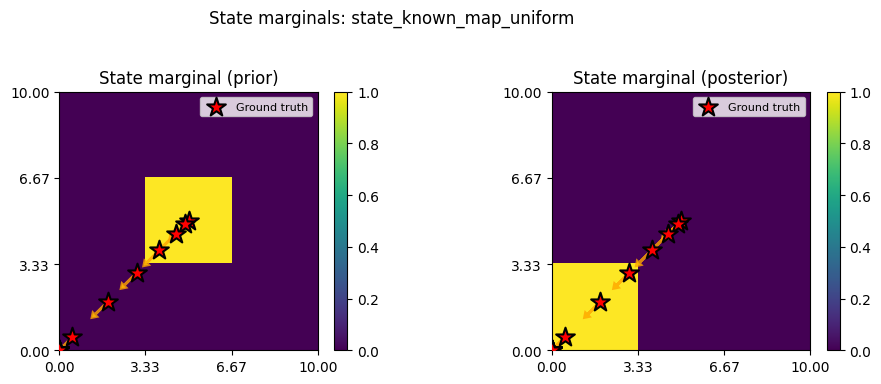

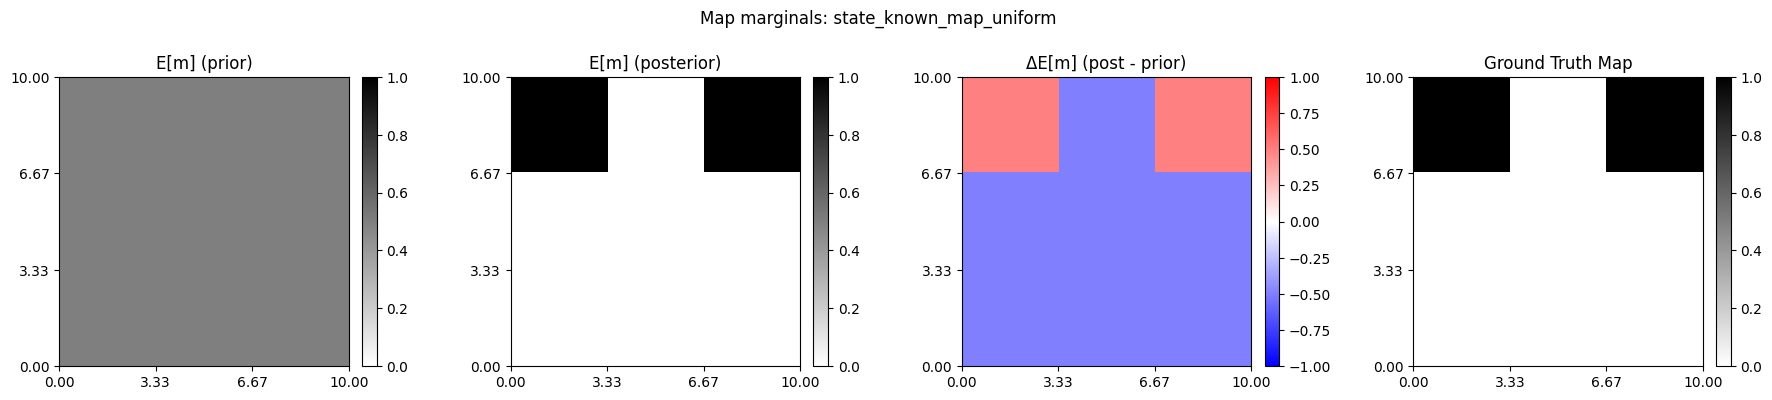

[ΔE[m]] uniform_state_map_known: mean NE=1.858e-295, SW=0.000e+00


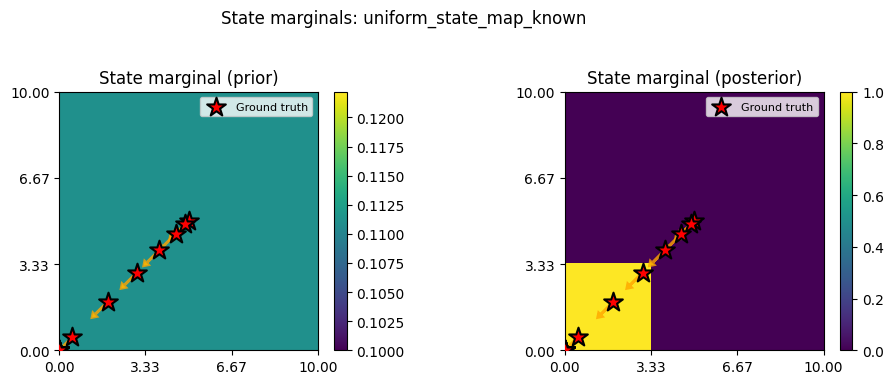

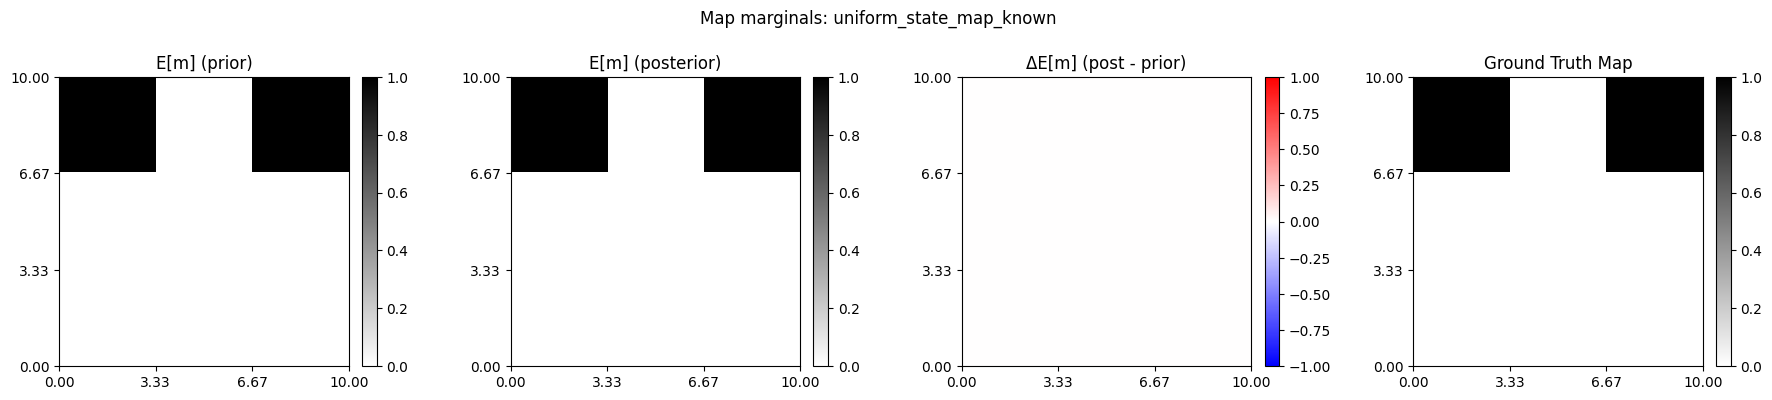


✓ Visualization complete. Figures displayed in notebook.


In [24]:
# Visualize F function results using visualize_results from test file
if 'results' in globals():
    print("\n" + "="*70)
    print("Visualizing F function results...")
    print("="*70 + "\n")
    
    
    # Use the adapted visualize_results function
    visualize_F_results(results)
else:
    print("⚠ Run the setup cell first to generate results for visualization")